In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [10]:
# ==========================================
# 0. Configuration parameters
# ==========================================
CONFIG = {
    'file_path': 'Adidas_US_Sales_Dataset.csv',
    'date_col': 'invoicedate',
    'target_col': 'totalsales',
    'train_ratio': 0.85
}

In [11]:
# ==========================================
# 1. Data cleansing
# ==========================================
def load_and_clean_data(config):
    try:
        df = pd.read_csv(config['file_path'], sep=None, engine='python')
    except Exception as e:
        df = pd.read_csv(config['file_path']) 
        
    df.columns = df.columns.str.lower().str.replace(' ', '')
    
    if df[config['target_col']].dtype == 'object':
        df[config['target_col']] = df[config['target_col']].astype(str).str.replace(r'[$\s,]', '', regex=True)
        df[config['target_col']] = pd.to_numeric(df[config['target_col']])

    df[config['date_col']] = pd.to_datetime(df[config['date_col']], format='%d/%m/%Y', errors='coerce')
    if df[config['date_col']].isnull().all():
        df[config['date_col']] = pd.to_datetime(df[config['date_col']])

    daily_df = df.groupby(config['date_col'])[config['target_col']].sum().reset_index()
    daily_df = daily_df.set_index(config['date_col'])
    daily_df = daily_df.resample('D').sum().fillna(0)
    daily_df = daily_df.reset_index()

    return daily_df

df_clean = load_and_clean_data(CONFIG)

In [12]:
# ==========================================
# 2. Building 'tabular' features for XGBoost
# ==========================================
def build_xgboost_features(df, config):
    data = df.copy()
    target = config['target_col']

    data['target_smooth'] = data[target].ewm(span=7, adjust=False).mean()
    
    # Lags
    data['lag_1'] = data['target_smooth'].shift(1)
    data['lag_2'] = data['target_smooth'].shift(2)
    data['lag_7'] = data['target_smooth'].shift(7)
    data['lag_14'] = data['target_smooth'].shift(14)
    data['lag_30'] = data['target_smooth'].shift(30)
    
    # ---------------- Rolling Windows ----------------
    data['rolling_mean_7'] = data['target_smooth'].shift(1).rolling(window=7).mean()
    data['rolling_std_7'] = data['target_smooth'].shift(1).rolling(window=7).std()

    # ---------------- Time Features ----------------
    date_series = data[config['date_col']]
    data['dayofweek'] = date_series.dt.dayofweek
    data['month'] = date_series.dt.month
    data['day'] = date_series.dt.day
    data['is_weekend'] = data['dayofweek'].isin([5, 6]).astype(int)

    data = data.dropna().reset_index(drop=True)
    
    return data

df_features = build_xgboost_features(df_clean, CONFIG)

In [13]:
# ==========================================
# 3. Split the training set and test set
# ==========================================
# Extract feature columns and target columns
features = ['lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_30', 
            'rolling_mean_7', 'rolling_std_7', 
            'dayofweek', 'month', 'day', 'is_weekend']
target = 'target_smooth'

X = df_features[features]
y = df_features[target]

train_size = int(len(df_features) * CONFIG['train_ratio'])

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]

In [14]:
# ==========================================
# 4. Define and train an XGBoost model
# ==========================================
print("Commencing XGBoost training...")

# Initialise the XGBoost regressor
xgb_model = xgb.XGBRegressor(
    n_estimators=200,          
    learning_rate=0.05,        
    max_depth=5,               
    subsample=0.8,             
    colsample_bytree=0.8,      
    random_state=42,
    objective='reg:squarederror'
)

# Train a model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50 
)

Commencing XGBoost training...
[0]	validation_0-rmse:887360.80065	validation_1-rmse:1214587.83231
[50]	validation_0-rmse:157281.83378	validation_1-rmse:360780.22319
[100]	validation_0-rmse:85331.05489	validation_1-rmse:323029.72663
[150]	validation_0-rmse:60176.45327	validation_1-rmse:317082.89613
[199]	validation_0-rmse:45238.82572	validation_1-rmse:312977.49662


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = loa

In [15]:
# ==========================================
# 5. Forecasting and Evaluation
# ==========================================
test_predictions = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
mae = mean_absolute_error(y_test, test_predictions)
r2 = r2_score(y_test, test_predictions)

print(f"\n[XGBoost Test set results] RMSE: {rmse:.2f}, MAE: {mae:.2f}, R² Score: {r2:.4f}")


[XGBoost Test set results] RMSE: 312977.49, MAE: 237052.15, R² Score: 0.8669


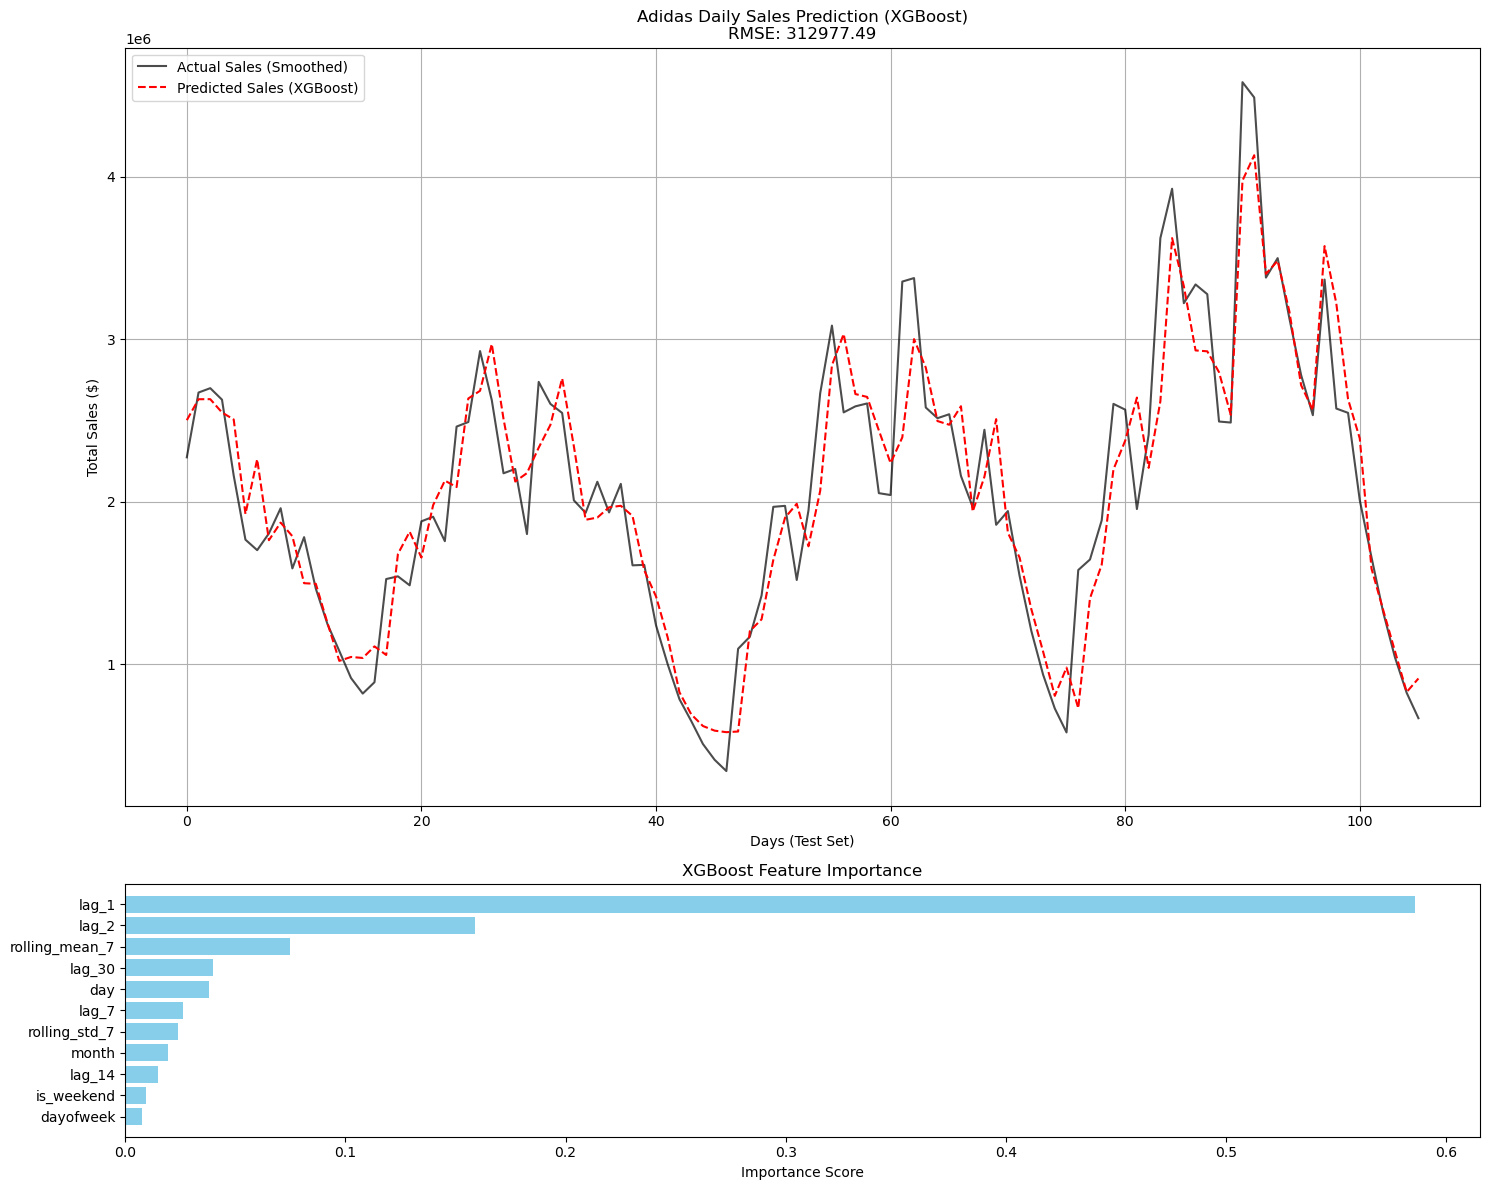

In [16]:
# ==========================================
# 6. Visualisation of feature importance and prediction curves
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), gridspec_kw={'height_ratios': [3, 1]})

# Plot a forecast curve
ax1.plot(y_test.values, label='Actual Sales (Smoothed)', color='black', alpha=0.7)
ax1.plot(test_predictions, label='Predicted Sales (XGBoost)', color='red', linestyle='--', linewidth=1.5)
ax1.set_title(f'Adidas Daily Sales Prediction (XGBoost)\nRMSE: {rmse:.2f}')
ax1.set_xlabel('Days (Test Set)')
ax1.set_ylabel('Total Sales ($)')
ax1.legend()
ax1.grid(True)

# Plot a bar chart of feature importance
importance = xgb_model.feature_importances_
feature_names = X_train.columns
sorted_idx = np.argsort(importance)

ax2.barh(range(len(sorted_idx)), importance[sorted_idx], align='center', color='skyblue')
ax2.set_yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
ax2.set_title('XGBoost Feature Importance')
ax2.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()